In [18]:
from visualizations import spike_plot_4x2, sixteen_tuning_curves, mean_var_scatter_4x4, mean_var_scatter_4x4_regression, violin_4row, violin_combined
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime
from matplotlib.ticker import MultipleLocator
from PIL import Image

### images with noise

In [14]:
image_stack = np.load('fnn//input_noise//saved_inputs_outputs//image_stack_july16.npy')

In [15]:
image_stack.shape

(5, 144, 256)

In [32]:
def show_image(img_arr, i = None):
    if i is not None: Image.fromarray(img_arr[i]).show()
    else: Image.fromarray(img_arr).show()

In [27]:
show_image(image_stack, 4)

In [37]:
from noise_seeds import generate_noise, stochastic_binarization

d3 = generate_noise('dynamic', 1, 3)
d15 = generate_noise('dynamic', 1, 15)
d30 = generate_noise('dynamic', 1, 30)
dbin = stochastic_binarization(image_stack[4])

In [ ]:
noise_image = np.clip(a = image_stack[4] + d30, a_min = 0, a_max = 255)[0] # just change noise type as needed

In [ ]:
noise_image.shape # ensure correct shape

(144, 256)

In [54]:
show_image(noise_image)

### loading data

In [2]:
# in real code we now labels_lst from np.unique() on region label output from predictions
labels_lst = [1,2,3,4]

string_path = 'fnn//input_noise//saved_inputs_outputs//predictions_july21//' # ex. path to predictions used from july

for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30', 'dbin', 'cbin', 'no_noise']:
    for type_noise in ['_sum', '_mean', '_var', '_labels']:
        file_name = string_path + noise + type_noise + '.npy'
        arr_name = noise + type_noise
        globals()[arr_name] = np.load(file_name)

# load predictions by region
for r in labels_lst:
    for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30', 'dbin', 'cbin', 'no_noise']:
        for type_noise in ['_sum', '_mean', '_var']:
            file_name = string_path + noise + type_noise + '_r' + str(r) + '.npy'
            arr_name = noise + type_noise + '_r' + str(r)
            globals()[arr_name] = np.load(file_name)

### making arrays

In [3]:
cmeans = [[c3_mean_r1, c15_mean_r1, c30_mean_r1, cbin_mean_r1],
                 [c3_mean_r2, c15_mean_r2, c30_mean_r2, cbin_mean_r2],
                 [c3_mean_r3, c15_mean_r3, c30_mean_r3, cbin_mean_r3],
                 [c3_mean_r4, c15_mean_r4, c30_mean_r4, cbin_mean_r4]]

cvars = [[c3_var_r1, c15_var_r1, c30_var_r1, cbin_var_r1],
               [c3_var_r2, c15_var_r2, c30_var_r2, cbin_var_r2],
               [c3_var_r3, c15_var_r3, c30_var_r3, cbin_var_r3],
               [c3_var_r4, c15_var_r4, c30_var_r4, cbin_var_r4]]

In [4]:
dmeans = [[d3_mean_r1, d15_mean_r1, d30_mean_r1, dbin_mean_r1],
                 [d3_mean_r2, d15_mean_r2, d30_mean_r2, dbin_mean_r2],
                 [d3_mean_r3, d15_mean_r3, d30_mean_r3, dbin_mean_r3],
                 [d3_mean_r4, d15_mean_r4, d30_mean_r4, dbin_mean_r4]]

dvars = [[d3_var_r1, d15_var_r1, d30_var_r1, dbin_var_r1],
               [d3_var_r2, d15_var_r2, d30_var_r2, dbin_var_r2],
               [d3_var_r3, d15_var_r3, d30_var_r3, dbin_var_r3],
               [d3_var_r4, d15_var_r4, d30_var_r4, dbin_var_r4]]

In [5]:
cviolin_means = [[c15_mean_r1, c30_mean_r1, cbin_mean_r1],
                 [c15_mean_r2, c30_mean_r2, cbin_mean_r2],
                 [c15_mean_r3, c30_mean_r3, cbin_mean_r3],
                 [c15_mean_r4, c30_mean_r4, cbin_mean_r4]]

cviolin_vars = [[c15_var_r1, c30_var_r1, cbin_var_r1],
                [c15_var_r2, c30_var_r2, cbin_var_r2],
                [c15_var_r3, c30_var_r3, cbin_var_r3],
                [c15_var_r4, c30_var_r4, cbin_var_r4]]

In [6]:
dviolin_means = [[d15_mean_r1, d30_mean_r1, dbin_mean_r1],
                 [d15_mean_r2, d30_mean_r2, dbin_mean_r2],
                 [d15_mean_r3, d30_mean_r3, dbin_mean_r3],
                 [d15_mean_r4, d30_mean_r4, dbin_mean_r4]]

dviolin_vars = [[d15_var_r1, d30_var_r1, dbin_var_r1],
                [d15_var_r2, d30_var_r2, dbin_var_r2],
                [d15_var_r3, d30_var_r3, dbin_var_r3],
                [d15_var_r4, d30_var_r4, dbin_var_r4]]

### plots

#### line plots

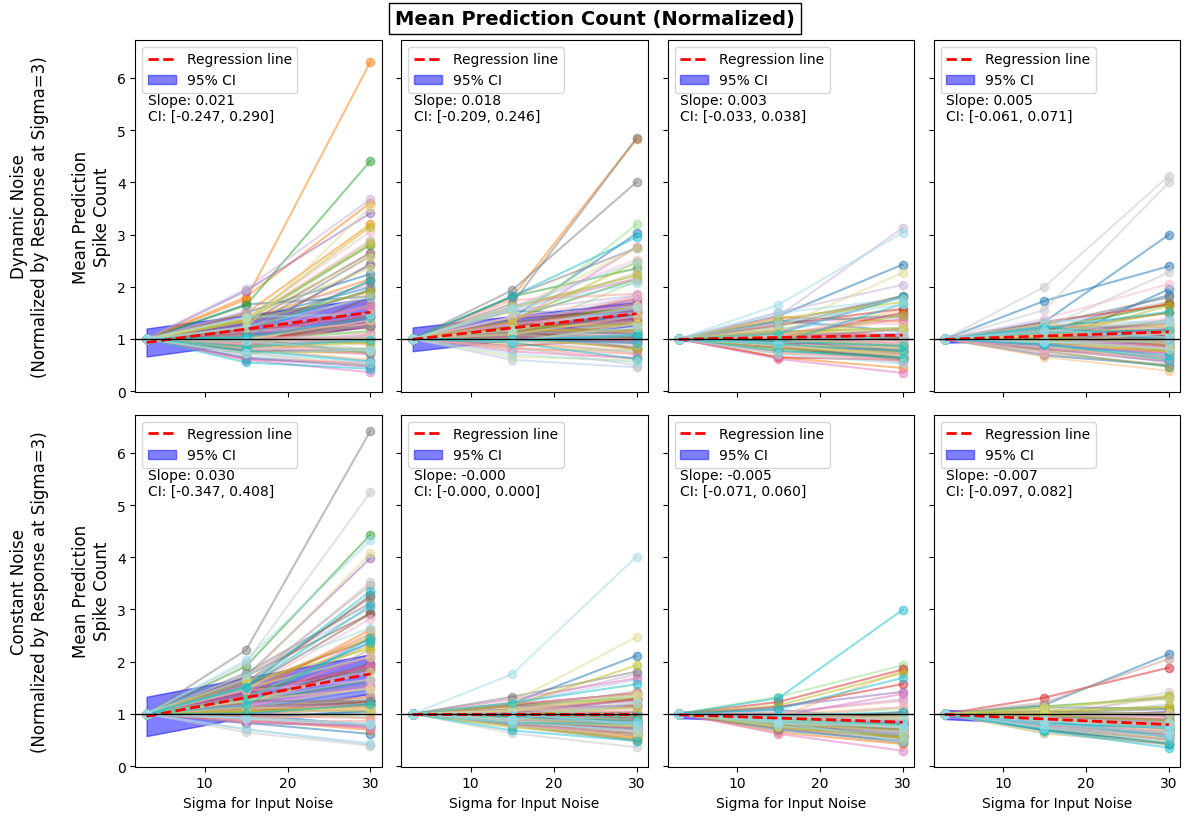

In [7]:
spike_plot_4x2('Mean Prediction Count (Normalized)', dmeans, cmeans, True)

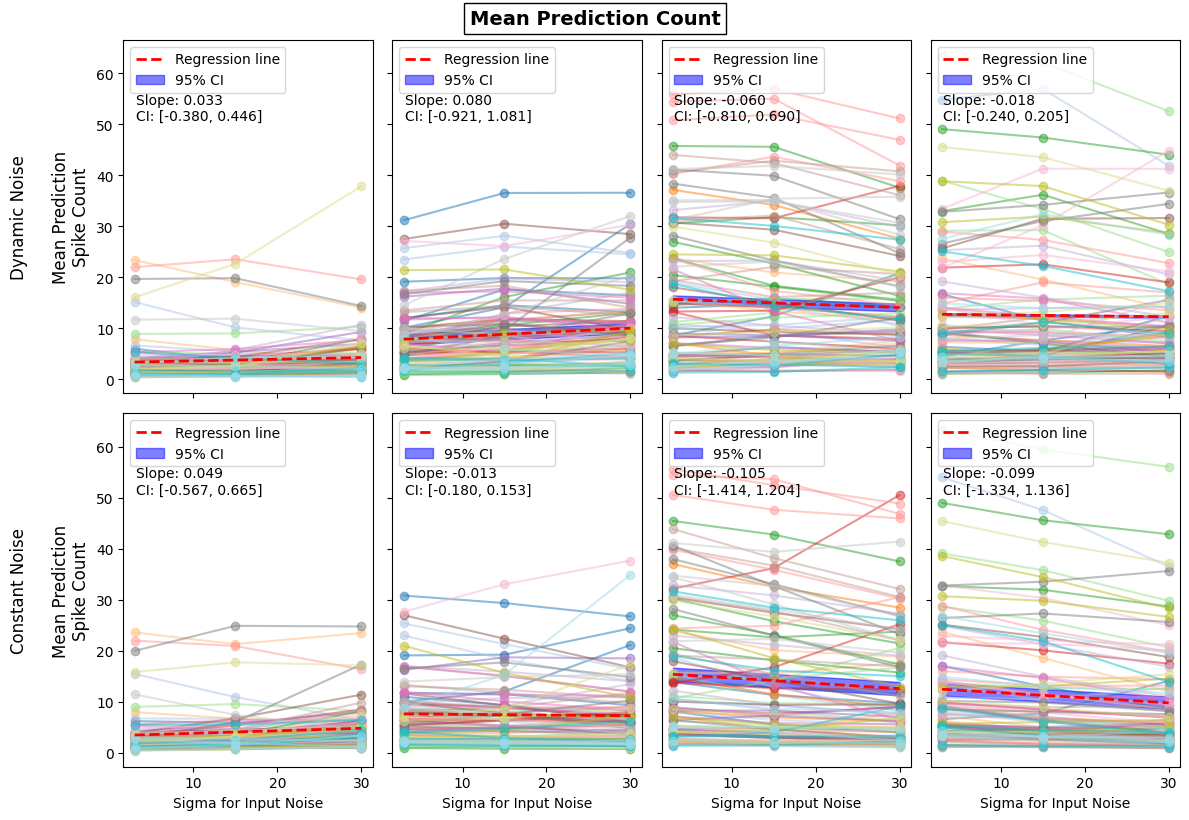

In [12]:
spike_plot_4x2('Mean Prediction Count', dmeans, cmeans, False)

#### tuning curves

In [13]:
csums = [[c3_sum_r1, c15_sum_r1, c30_sum_r1, cbin_sum_r1],
                 [c3_sum_r2, c15_sum_r2, c30_sum_r2, cbin_sum_r2],
                 [c3_sum_r3, c15_sum_r3, c30_sum_r3, cbin_sum_r3],
                 [c3_sum_r4, c15_sum_r4, c30_sum_r4, cbin_sum_r4]]

In [14]:
tuning_titles = ['Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic Binarization']

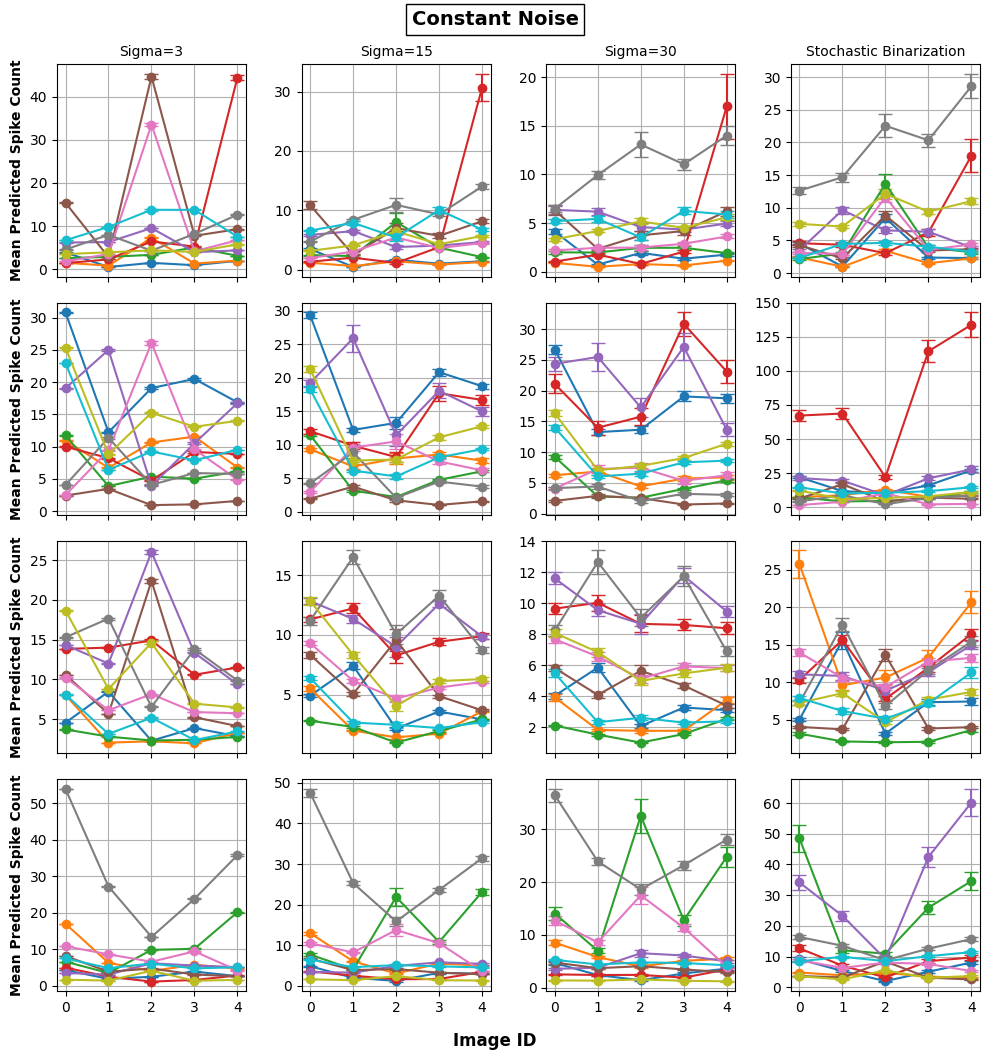

In [15]:
sixteen_tuning_curves(csums, 'Constant Noise', tuning_titles)

In [16]:
dsums = [[d3_sum_r1, d15_sum_r1, d30_sum_r1, dbin_sum_r1],
                 [d3_sum_r2, d15_sum_r2, d30_sum_r2, dbin_sum_r2],
                 [d3_sum_r3, d15_sum_r3, d30_sum_r3, dbin_sum_r3],
                 [d3_sum_r4, d15_sum_r4, d30_sum_r4, dbin_sum_r4]]

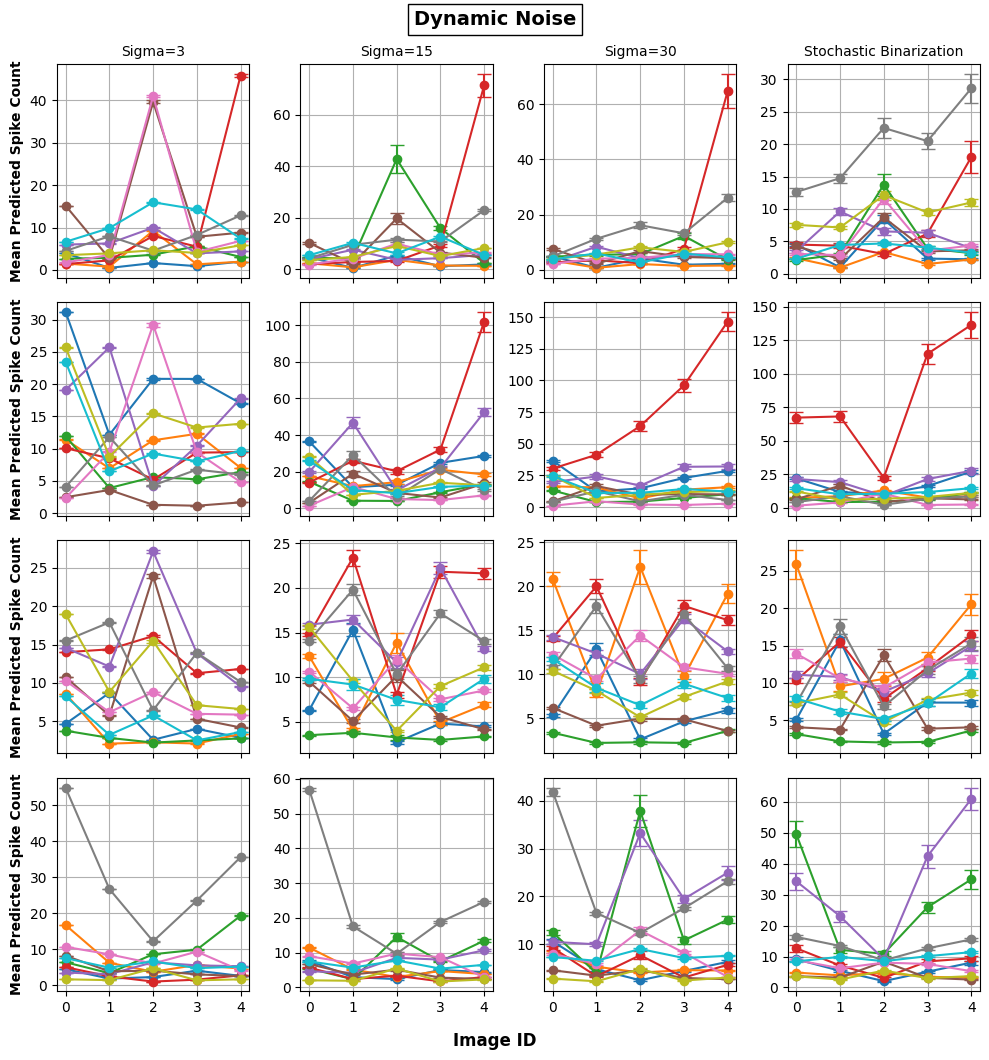

In [17]:
sixteen_tuning_curves(dsums, 'Dynamic Noise', tuning_titles)

#### mean var scatter

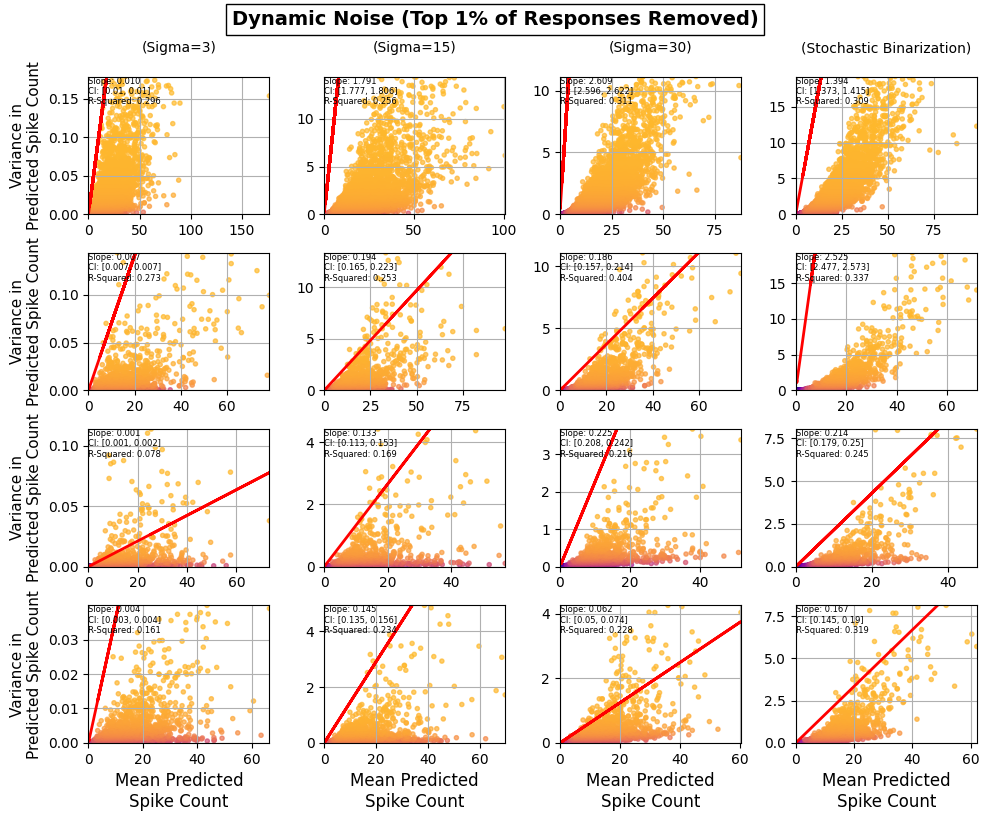

In [24]:
# run arrays before this cell
mean_var_scatter_4x4(dmeans, dvars, 'Dynamic Noise (Top 1% of Responses Removed)', False, 'top', 1)

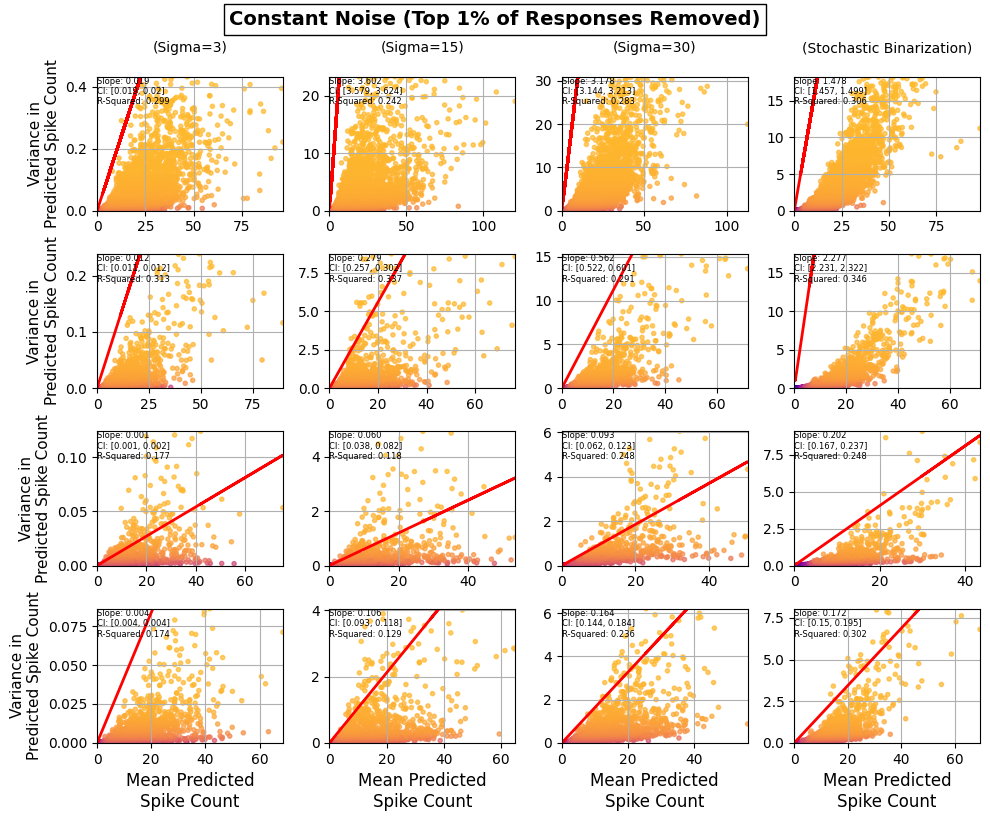

In [25]:
mean_var_scatter_4x4(cmeans, cvars, 'Constant Noise (Top 1% of Responses Removed)', False, 'top', 1)

#### mean var scatter regression

In [26]:
# region 1
r1_randoms = [2322, 3279, 4060, 1756,  146, 4441, 3978, 2034, 5025, 3515, 3534,
       2167, 2310, 1837, 3864, 2529, 4127, 2325, 4791,  314, 3371, 1857,
       1095, 1917, 3097, 1722, 4344, 3627, 3930, 3459]
# region 2
r2_randoms = [958, 907, 514, 432, 594, 385, 184, 368, 525, 351, 302, 551, 550,
       575, 375, 719, 242, 613, 789, 872, 340, 402, 397, 643, 255, 928,
       471, 894, 281, 523]
# region 3
r3_randoms = [279, 337, 208, 128,  46, 115, 248, 197,  52, 269,  37, 364, 340,
       203,  36, 153,  84, 278,  71, 115,  24,  78, 138,  38,  22,  17,
        89, 349, 178, 332]
# region 4
r4_randoms = [376, 295, 517,  25, 663, 429, 427, 651, 133, 500, 689, 266, 470,
       424,  90, 560, 290, 198, 149, 181, 749, 461, 658, 771, 367, 758,
       125, 195, 191,   8]

randoms = [r1_randoms, r2_randoms, r3_randoms, r4_randoms]

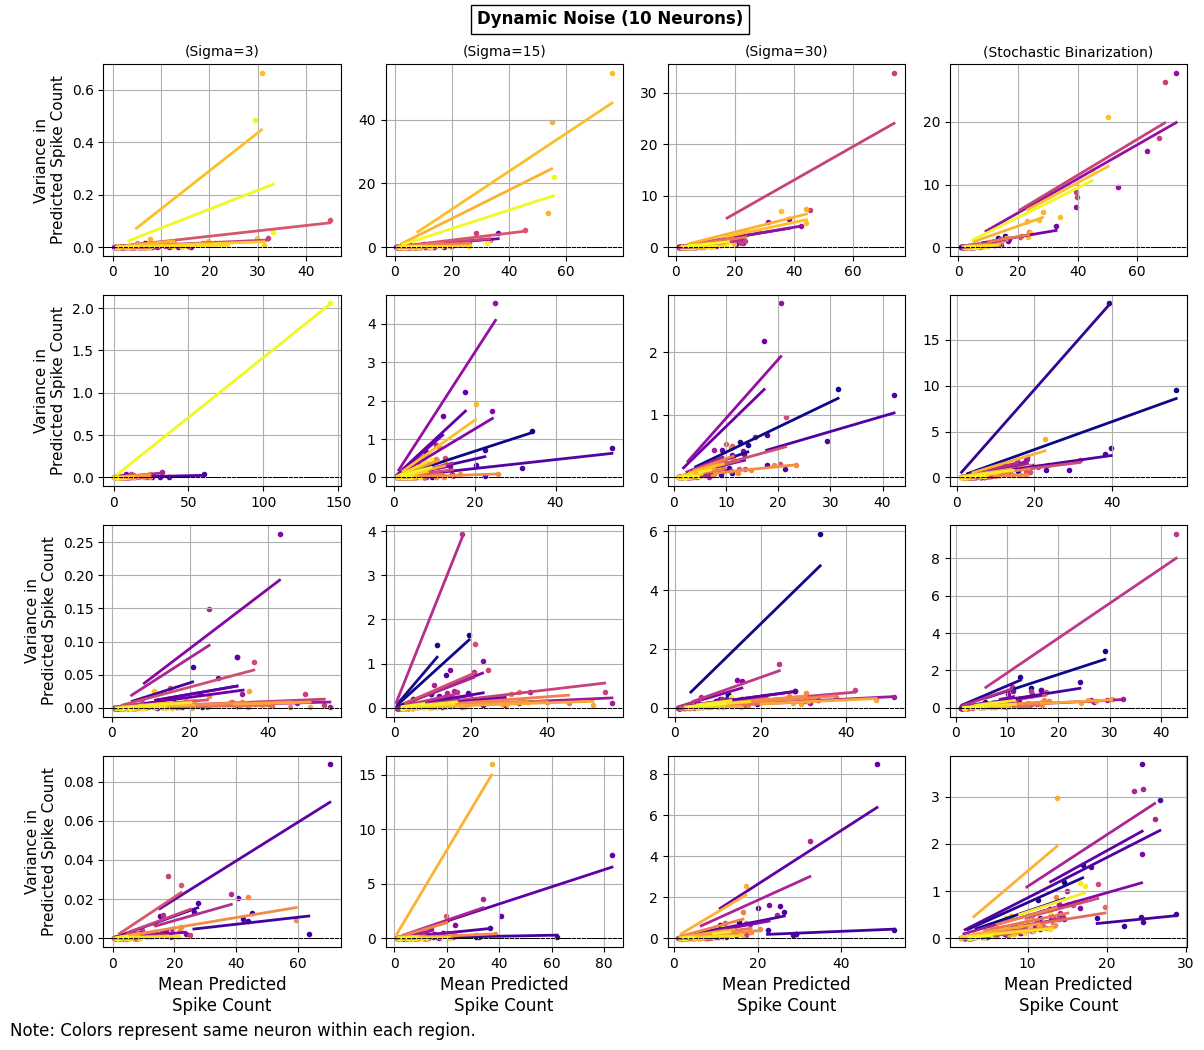

In [27]:
mean_var_scatter_4x4_regression(dmeans, dvars, randoms, 'Dynamic Noise (10 Neurons)')

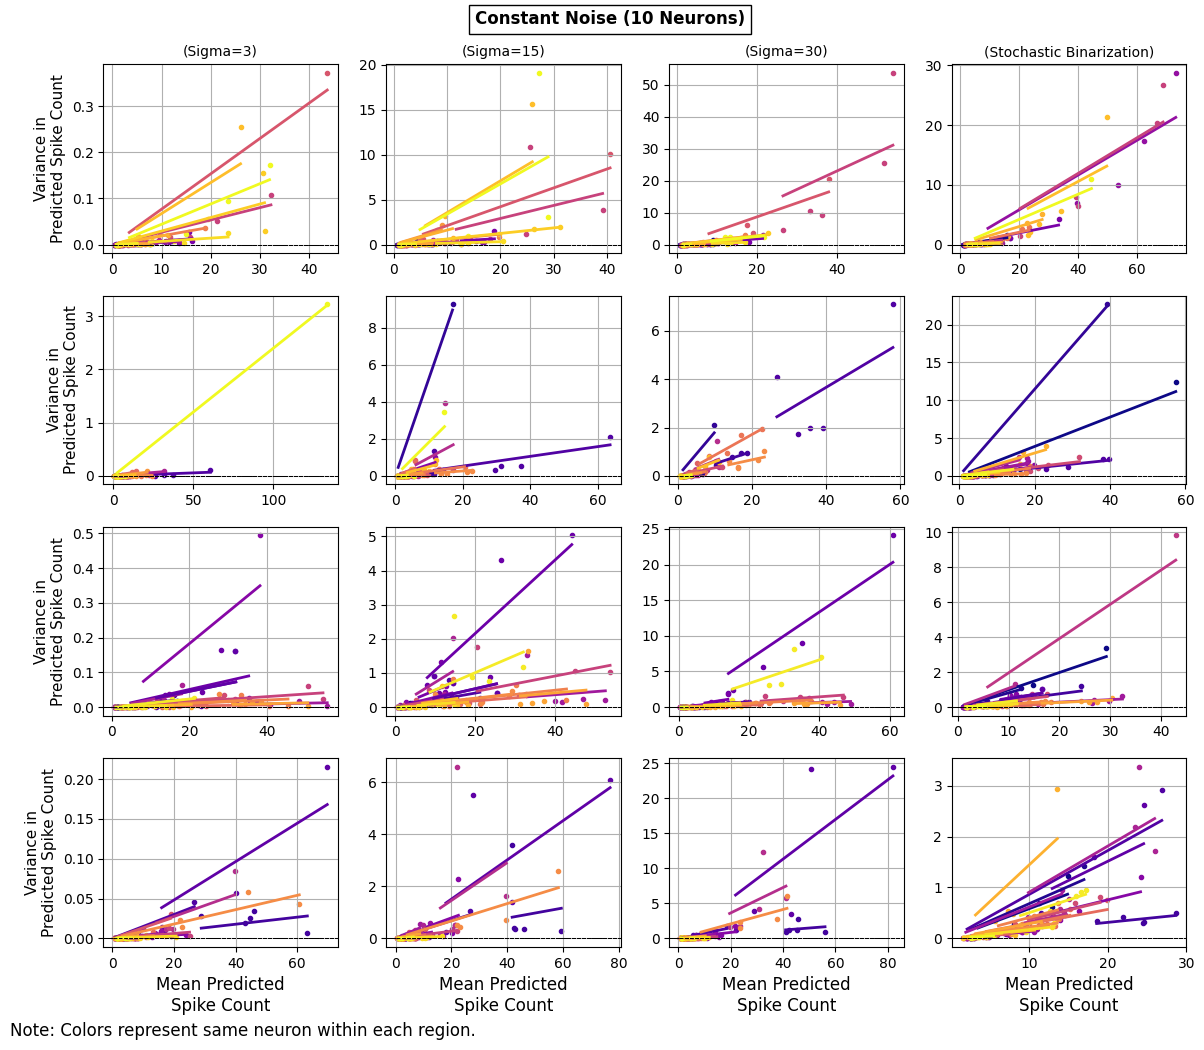

In [28]:
mean_var_scatter_4x4_regression(cmeans, cvars, randoms, 'Constant Noise (10 Neurons)')

#### violin 1

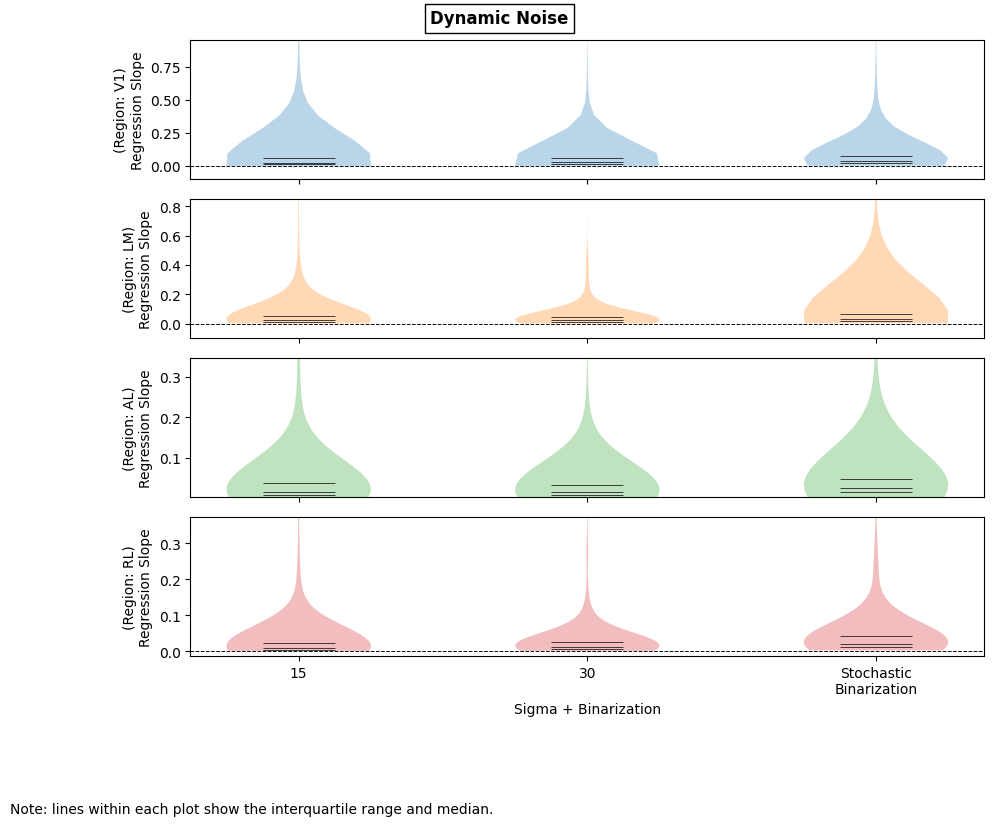

In [8]:
violin_4row(dviolin_means, dviolin_vars, 'Dynamic Noise')

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from processing import remove_x

def violin_4row(means, vars, main_title: str, savefig: bool = False, remove_x_str: str = None, remove_x_percent: int = None): # first violin plot in presentation results
    """
    Parameters
    ----------
    means: list
        list of mean arrays, must be 2d list
    vars: list
        list of varriance arrays, must be 2d list
    main_title: str
        main title for plot
    savefig: bool
        to save figure in current directory, defaults to False
    remove_x_str: str
        to remove top, bottom or None % of data, defaults to None
    Remove_x_percent: int
        to remove x % of data, defaults to None

    Returns
    -------
    plot
        4x4 violin plot for each region and sigma/binarization (region 3 excluded)

    """
    
    fig, axes = plt.subplots(len(means), 1, figsize=(10, 8), sharex=True, sharey=False)
    fig.text(0.5, 1.02, main_title, ha='center', va='top', fontsize=12, fontweight = 'bold', bbox=dict(facecolor='white'))
    violin_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 
    violin_colors = [violin_colors[i] for i in range(len(means))]
    for i in range(len(means)):
        ax = axes[i] 
        
        region_x = means[i]
        region_y = vars[i]
        slope_list = []

        for mean_arr, var_arr in zip(region_x, region_y):
            slope_temp = []
            for neuron in range(mean_arr.shape[1]):
                neuron_x = mean_arr[:, neuron].reshape(-1,1)
                neuron_y = var_arr[:, neuron]
                linregress_neuron = LinearRegression(fit_intercept = True).fit(neuron_x, neuron_y)
                slope_temp.append(linregress_neuron.coef_[0])
            slope_list.append(slope_temp)
        
        # method 1, remove x
        if remove_x_str is not None and remove_x_percent is not None:
            for region_slopes in slope_list:
                region_slopes = remove_x(region_slopes, remove_x_str, remove_x_percent)

        vp = ax.violinplot(slope_list, showmeans = False, showmedians = True, showextrema = False, bw_method = 0.75,
                           quantiles = [[0.25, 0.75] for _ in range(len(slope_list))])


        vp['cquantiles'].set_color('black')  
        vp['cquantiles'].set_linewidth(0.25)

        for body in vp['bodies']:
            body.set_facecolor(violin_colors[i])
        for element in ['cmedians']:
            vp[element].set_color('black')
                
        for element in ['cquantiles', 'cmedians']: vp[element].set_linewidth(0.5)

        if i == 0: title_region = 'V1' 
        elif i == 1: title_region = 'LM'
        elif i == 2: title_region = 'AL'
        else: title_region = 'RL'

        ax.set_ylabel(f'(Region: {title_region})\nRegression Slope', fontsize = 10)
        
        tick_labels = ['15', '30', 'Stochastic\nBinarization']
        if i == 3: ax.set_xticks([i+1 for i, _ in enumerate(tick_labels)])
        if i == 3: ax.set_xticklabels(tick_labels)  
        if i == 3: ax.set_xlabel('Sigma + Binarization')
        
        # method 2, set y_lim (adjusting differently for D and C plots)
        if i == 0 or i == 1: ax.set_ylim(min([np.min(arr) for arr in slope_list] + [-0.1]),.1 * max([np.max(arr) for arr in slope_list]))
        elif i == 2: ax.set_ylim(1.5 * min([np.min(arr) for arr in slope_list] + [0.1]), .2 * max([np.max(arr) for arr in slope_list]))
        else: ax.set_ylim(1.5 * min([np.min(arr) for arr in slope_list] + [-0.1]), .4 * max([np.max(arr) for arr in slope_list]))
        ax.axhline(y=0, linestyle = '--', color = 'black', linewidth = 0.7)

    
    plt.text(0, -.45, 'Note: lines within each plot show the interquartile range and median.')
    plt.tight_layout()
    if savefig: 
        try:
            date = datetime.now()
            file_date = f'({str(date.month)}-{str(date.day)}-{str(date.year)})'
            path_name = f'{main_title}_{file_date}.pdf'
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name), 
                        bbox_inches = 'tight', pad_inches = 0.3)
        except FileNotFoundError:
            os.makedirs(f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', exist_ok = True)
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name),
                        bbox_inches = 'tight', pad_inches = 0.3)
            plt.close()
    else: plt.show()

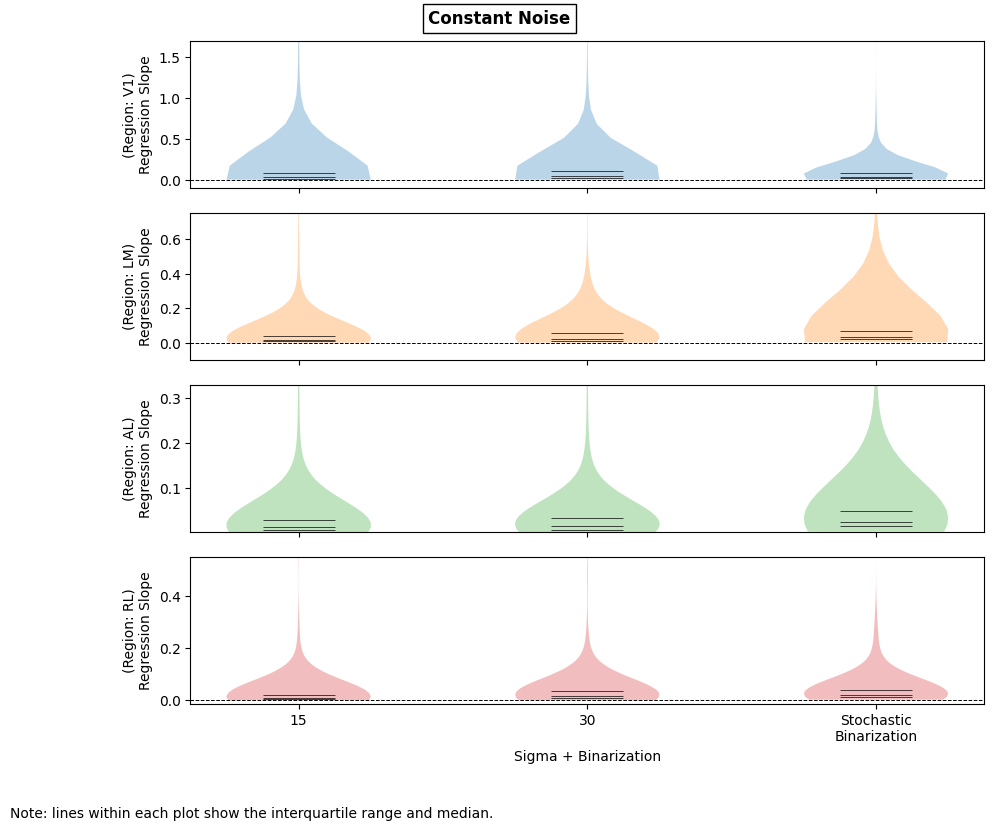

In [9]:
violin_4row(cviolin_means, cviolin_vars, 'Constant Noise')

#### violin 2

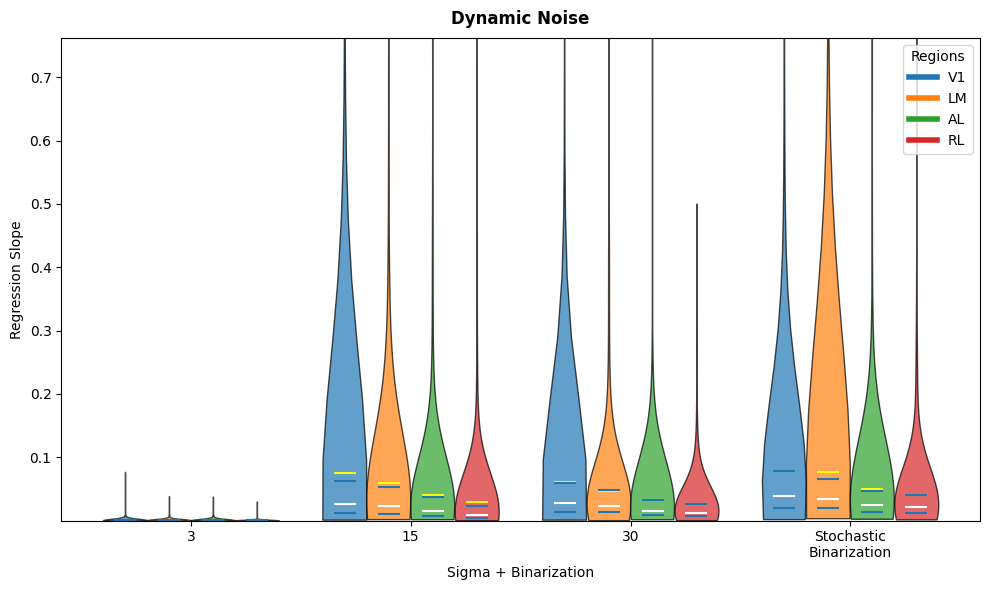

In [32]:
violin_combined(dmeans, dvars, 'Dynamic Noise')

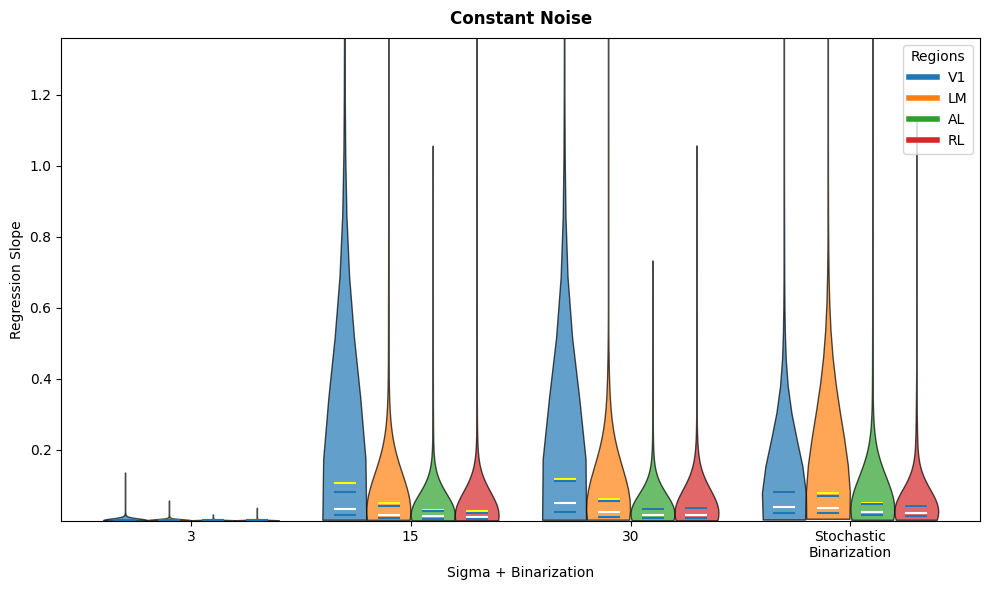

In [7]:
violin_combined(cmeans, cvars, 'Constant Noise')